# Music Genre Classification & Wine Quality Clustering

A two-part machine learning project in Python (pandas, scikit-learn, matplotlib, seaborn).

| Part | Task | Method | Data |
|---|---|---|---|
| 1 | Multi-class classification (10 music genres) | SVM (RBF kernel) vs Random Forest | Audio-feature dataset |
| 2 | Unsupervised clustering | K-Means + PCA visualisation | UCI Red Wine Quality |

**What this notebook covers**
- Stratified train/test split, feature standardisation (scaler fitted on training data only to avoid leakage)
- Model comparison with confusion matrices and per-class precision/recall/F1
- Error analysis of why genres such as Rap/Hip-hop and Alternative/Rock get confused
- Choosing k with the elbow method and interpreting clusters through their centroids

**Key results:** SVM (~58% accuracy) slightly outperformed Random Forest (~57%) on a 10-class problem. K-Means (k = 3) split the wines into three chemically distinct groups.

> Data files are expected in the same folder as the notebook (`FIT1043-MusicGenre-Dataset.csv`, `FIT1043-MusicGenre-Submission.csv`, `winequality-red.csv`).

---
# Part 1: Music Genre Classification

## 1.1 Background: Supervised Learning

### What is supervised machine learning 
Machine learning is a branch of artificial intelligence in which a model is trained to learn a mapping from inputs to outputs by training on a labeled dataset. In supervised learning, we provide the algorithm with a dataset of input–output pairs, and the goal is for the algorithm to learn the relationship so it can predict outputs. Usually supervised machine learning involves tasks revolving around classification and regression.

### The notion of labelled data
Labelled data is data in which each input is paired with a correct or corresponding label. This label is crucial as it guides the model to learn the relationship between inputs and outputs by telling the model what the right answer is for each example.

### Training vs Test dataset
The training set is used to fit the model's parameters; the model learns patterns by minimizing prediction errors on this data.

The test set is never used for training. After training, we feed its features into the learned model and compare its predictions to the true labels to measure performance.

### Importance in model evaluation
Evaluation lets us detect overfitting and underfitting. An overfitted model performs very well on training data but poorly on test data; an underfitted model is too simple to capture the patterns and performs poorly on both.


## 1.2 Loading the Data

In [977]:
import pandas as pd
import numpy as np

df = pd.read_csv('FIT1043-MusicGenre-Dataset.csv')
X = df.iloc[:, 3:-1].values
y = df.iloc[:, -1].values

## 1.3 Data Quality Check

In [979]:
#Check whether there is a missing value
df.isnull().sum()

instance_id         0
artist_name         0
track_name          0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
music_genre         0
dtype: int64

### Observations
There are no missing values in the dataset, and all features are numeric.

## 1.4 Train/Test Split

In [982]:
from sklearn.model_selection import train_test_split

# 80/20 stratified split so every genre keeps the same proportion in both sets
# Fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=682, stratify=y
)

## 1.5 Problem Type: Multi-class Classification

Binary classification has exactly two possible labels (e.g. travel / no travel), usually encoded as 0 or 1.

Multi-class classification has three or more labels. Here the target is the `music_genre` column, which has 10 possible classes (e.g. Rock, Jazz, Rap).

## 1.6 Feature Scaling

Scaling prevents features measured on large scales from dominating those on small scales, so each feature contributes fairly and model performance improves. Standardisation subtracts each feature's mean and divides by its standard deviation.

The scaler is **fitted on the training set only** and then applied to the test set with `transform()`, so no information from unseen data leaks into training.

In [985]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 1.7 Support Vector Machine (SVM)

SVM is a supervised model used for classification and regression. It finds the hyperplane that best separates the classes by maximising the margin between the nearest points of each class.

**Kernel function:** the kernel implicitly maps inputs into a higher-dimensional space so that non-linearly separable data can be separated by a hyperplane, without explicitly computing the new features (which would be expensive). This project uses the RBF kernel with `C=4.3` and `class_weight='balanced'`.

### References: SVM

1. https://scikit-learn.org/stable/modules/svm.html#kernel-functions
2. https://www.geeksforgeeks.org/support-vector-machine-algorithm/

In [988]:
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize SVM classifier
model = svm.SVC(
    kernel='rbf',  
    C=4.3,         
    gamma='scale',  
    class_weight='balanced'
)
# Train the model
model.fit(X_train, y_train)

SVC(C=4.3, class_weight='balanced')

## 1.8 Random Forest

Random Forest is an ensemble of decision trees trained on random subsets of the data and features; the final class is chosen by majority vote. It is used here as a comparison baseline for the SVM (500 trees, entropy criterion).

### References: Random Forest

1. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [991]:
# Fitting Random Forest Classification to the Training set
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(
    n_estimators = 500,
    criterion = 'entropy',
    random_state = 42
)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=500, random_state=682)

## 1.9 Generating Predictions

In [993]:
# Predict on validation set
y_pred = model.predict(X_test)

In [994]:
# Predicting the Test set results
y_pred_rf = classifier.predict(X_test)

## 1.10 Confusion Matrices

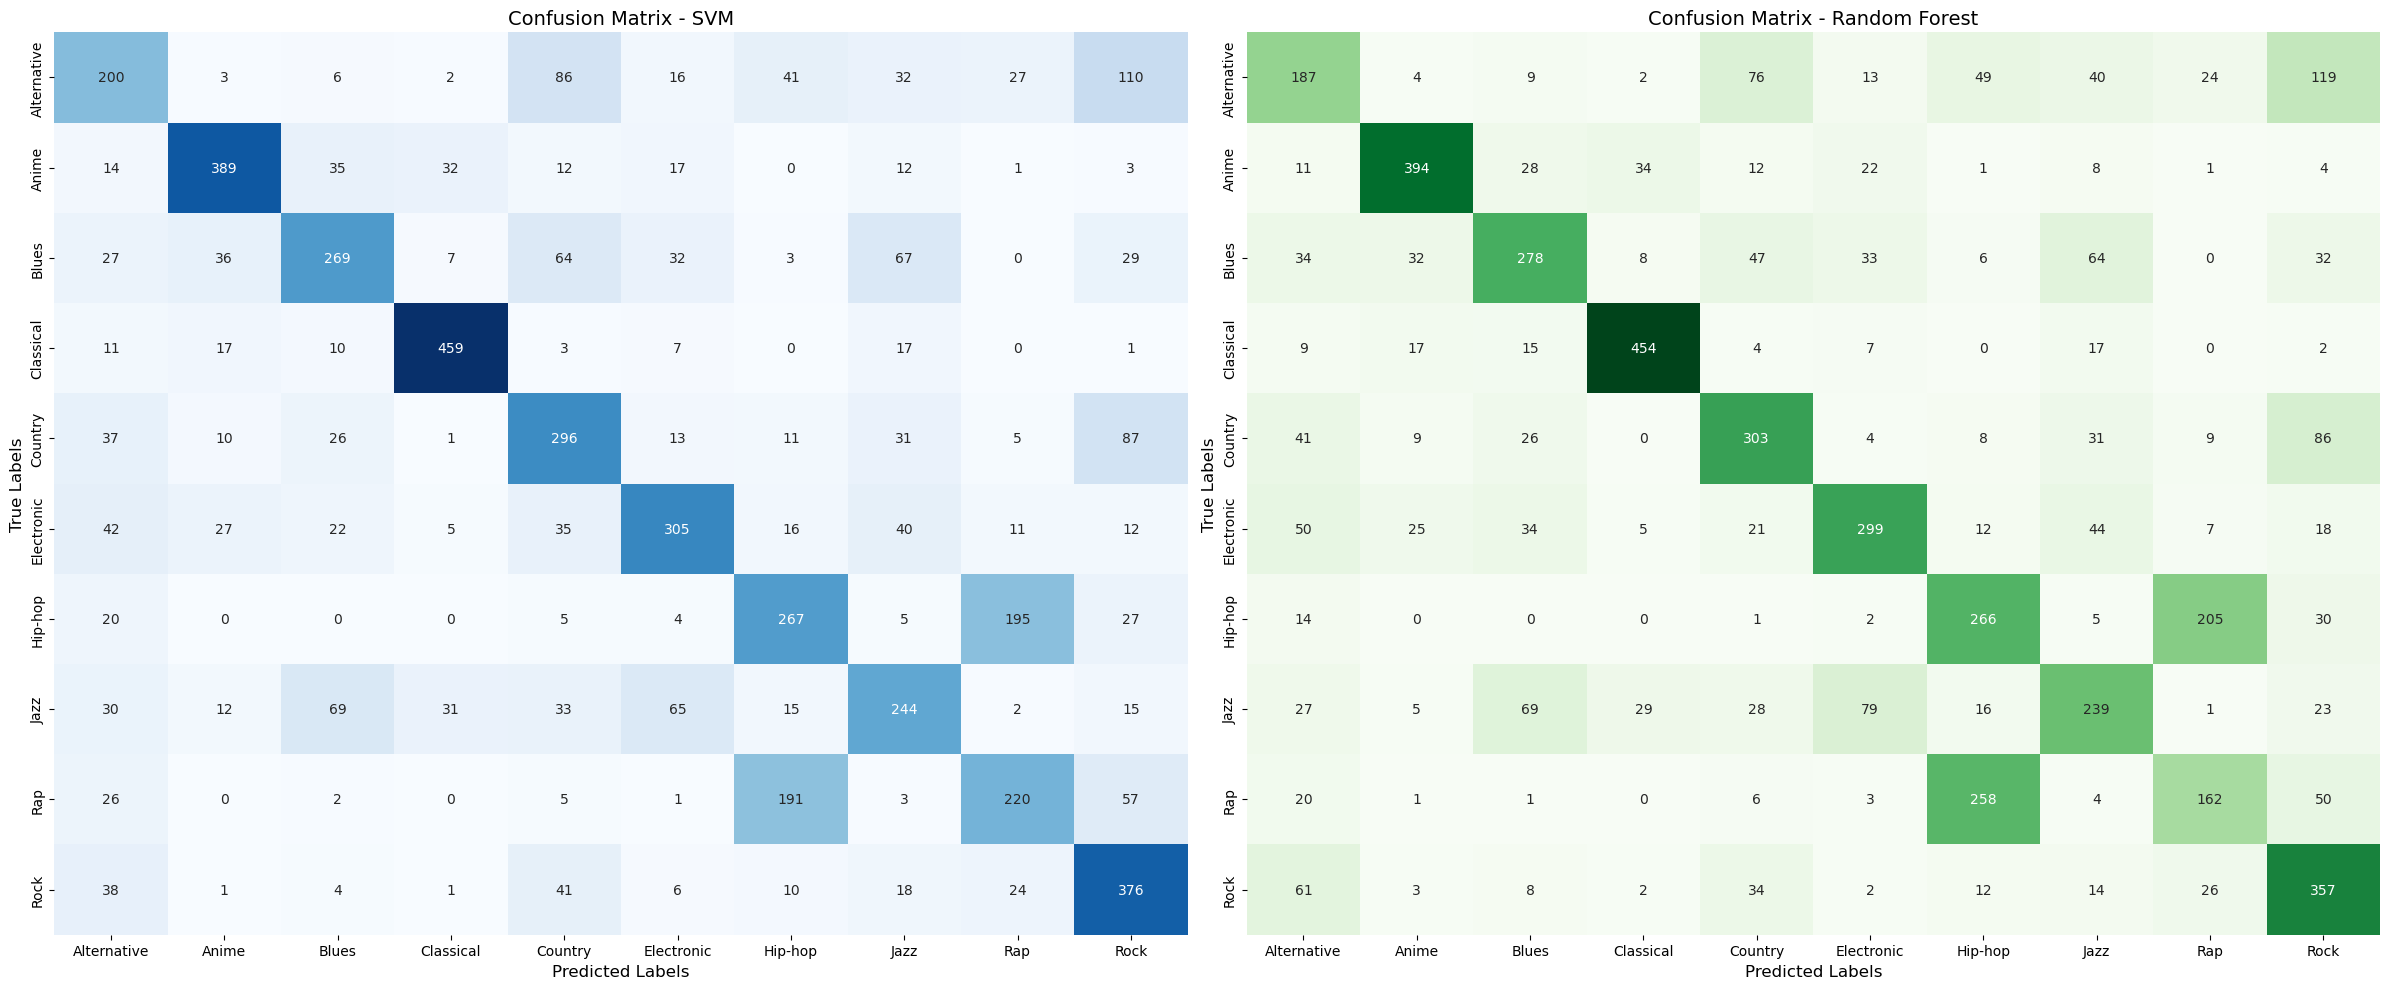

In [996]:
import matplotlib.pyplot as plt
import seaborn as sns

cm1 = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred_rf)
music_genre = ["Alternative", "Anime", "Blues", "Classical", "Country", "Electronic", "Hip-hop", "Jazz", "Rap", "Rock"]

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Plot for Model 1
sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    cbar=False,
    xticklabels=music_genre,
    yticklabels=music_genre
)
axes[0].set_title("Confusion Matrix - SVM", fontsize=14)
axes[0].set_xlabel("Predicted Labels", fontsize=12)
axes[0].set_ylabel("True Labels", fontsize=12)
axes[0].tick_params(axis='both', labelsize=10)

# Plot for Model 2
sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1],
    cbar=False,
    xticklabels=music_genre,
    yticklabels=music_genre
)
axes[1].set_title("Confusion Matrix - Random Forest", fontsize=14)
axes[1].set_xlabel("Predicted Labels", fontsize=12)
axes[1].set_ylabel("True Labels", fontsize=12)
axes[1].tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

## 1.11 Model Evaluation

In [998]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Validation Accuracy for SVM: {accuracy * 100:.2f}%")

# Generate classification report 
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Validation Accuracy for SVM: 58.26%

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.38      0.41       523
           1       0.79      0.76      0.77       515
           2       0.61      0.50      0.55       534
           3       0.85      0.87      0.86       525
           4       0.51      0.57      0.54       517
           5       0.65      0.59      0.62       515
           6       0.48      0.51      0.50       523
           7       0.52      0.47      0.50       516
           8       0.45      0.44      0.44       505
           9       0.52      0.72      0.61       519

    accuracy                           0.58      5192
   macro avg       0.58      0.58      0.58      5192
weighted avg       0.58      0.58      0.58      5192



In [999]:
# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Validation Accuracy for Random Forest: {accuracy_rf * 100:.2f}%")

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Validation Accuracy for Random Forest: 56.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.36      0.38       523
           1       0.80      0.77      0.78       515
           2       0.59      0.52      0.55       534
           3       0.85      0.86      0.86       525
           4       0.57      0.59      0.58       517
           5       0.64      0.58      0.61       515
           6       0.42      0.51      0.46       523
           7       0.51      0.46      0.49       516
           8       0.37      0.32      0.34       505
           9       0.50      0.69      0.58       519

    accuracy                           0.57      5192
   macro avg       0.57      0.57      0.56      5192
weighted avg       0.57      0.57      0.56      5192



### Which algorithm performed better?

SVM performed slightly better than Random Forest. With `C=4.3` the SVM balances a wide margin against tolerating some misclassifications, producing smooth boundaries in the transformed (RBF) space, whereas trees make axis-aligned, locally greedy splits.

## 1.12 Error Analysis

In [1002]:
import pandas as pd

feature_columns = df.columns[3:-1].tolist()  

# Create a DataFrame of test data with features and labels
test_df = pd.DataFrame(X_test, columns=feature_columns)
test_df['True_Genre'] = y_test
test_df['Predicted_Genre'] = y_pred

# Identify misclassified records
misclassified = test_df[test_df['True_Genre'] != test_df['Predicted_Genre']]

# Filter misclassified records for Class 0 and Class 8
worst_genres = [0, 8]
examples = {}

for genre in worst_genres:
    # Get 2 misclassified examples where the TRUE label is the worst-performing genre
    genre_misclassified = misclassified[misclassified['True_Genre'] == genre].sample(2)
    examples[genre] = genre_misclassified

# Display features and labels for Class 0 and Class 8 errors
for genre, df_examples in examples.items():
    print(f"\nMisclassified Examples for Genre {genre} (True Label = {genre}):")
    display(df_examples[feature_columns + ['True_Genre', 'Predicted_Genre']])

# Correctly classified examples of Class 0 and Class 8
correct_class0 = test_df[(test_df['True_Genre'] == 0) & (test_df['Predicted_Genre'] == 0)].sample(2)
correct_class8 = test_df[(test_df['True_Genre'] == 8) & (test_df['Predicted_Genre'] == 8)].sample(2)

print("\nCorrectly Classified Class 0 (Alternative):")
display(correct_class0[feature_columns + ['True_Genre', 'Predicted_Genre']])

print("\nCorrectly Classified Class 8 (Rap):")
display(correct_class8[feature_columns + ['True_Genre', 'Predicted_Genre']])


Misclassified Examples for Genre 0 (True Label = 0):


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,True_Genre,Predicted_Genre
2098,0.120290,-0.897668,0.186343,-0.340054,1.348576,-0.560954,-0.673861,0.908689,-0.558855,-0.945496,1.570565,0,4
1901,0.764105,-0.696408,0.203109,0.650393,-1.273063,-0.552718,0.383468,-0.230078,-0.582284,0.119332,-0.974858,0,9



Misclassified Examples for Genre 8 (True Label = 8):


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,True_Genre,Predicted_Genre
1736,1.214776,1.281413,-0.445170,0.441776,-0.771368,-0.560939,0.432761,0.200465,1.164162,-1.485014,-1.160126,8,6
2417,1.858592,-0.287869,0.387533,-0.249445,0.756350,-0.560577,-0.349761,0.358028,0.666293,1.831522,1.828330,8,6



Correctly Classified Class 0 (Alternative):


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,True_Genre,Predicted_Genre
4098,0.635342,-0.889836,-0.797252,-0.268851,0.684679,-0.560954,-0.417539,0.357704,-0.566664,0.756054,-0.793617,0,0
1699,0.377816,-0.871163,-1.736138,0.087717,1.016627,-0.560927,-0.606084,0.125088,-0.386065,1.813352,0.575756,0,0



Correctly Classified Class 8 (Rap):


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,True_Genre,Predicted_Genre
3342,1.343540,-0.847492,0.549603,0.012076,-0.778912,-0.559105,-0.637508,-0.005891,3.145876,-0.847801,0.309937,8,8
1244,1.922974,-0.580100,0.924040,-0.408641,0.499844,-0.560954,1.788312,0.589997,-0.071724,-0.487238,0.181054,8,8


### Why these errors happened

The classification report and the sampled misclassifications show that the SVM struggles most with **Alternative** (F1 = 0.41, precision 0.45, recall 0.38) and **Rap** (F1 = 0.44, precision 0.45, recall 0.44). Overall accuracy is only about 58% (SVM) and 57% (Random Forest), so these confusions are not a quirk of one model.

**1. Rap is mistaken for Hip-hop.** The two genres are musically very close. Both have high speechiness and danceability and similar tempo, so in the standardised audio-feature space their points overlap heavily and the RBF boundary cannot separate them cleanly. The sampled errors show Rap tracks predicted as Hip-hop.

**2. Alternative is mistaken for Rock (and Country).** Alternative is a broad, heterogeneous label that covers many sub-styles, so its tracks spread across the feature space. They overlap with Rock in energy, loudness and acousticness, and some sit close to Country. The sampled errors include Alternative predicted as Rock and as Country. Rock has high recall (0.72) but lower precision (0.52), meaning the model tends to over-predict Rock and absorb tracks from neighbouring genres, which also lowers the recall of Alternative.

**3. Limits of the data.** The features describe only the audio (no lyrics, artist or release-era information), and genre labels are partly subjective, so some tracks genuinely sit between two genres. Using `class_weight='balanced'` helps minority classes but cannot fix classes that overlap in feature space.

**Possible improvements:** add engineered features (e.g. interaction between speechiness and tempo), add text or artist information, tune hyperparameters per class pair, or use a hierarchical classifier that first separates broad groups and then splits similar genres such as Rap vs Hip-hop.

## 1.13 Predicting on Unseen Data

In [1005]:
# Load the submission dataset
submission_df = pd.read_csv('FIT1043-MusicGenre-Submission.csv')

# Extract features 
X_submission = submission_df.iloc[:, 3:].values 
instance_ids = submission_df['instance_id'].values 

# Scale the submission features using the scaler already fitted on the training data (section 1.6).
# Only transform() is used here, so the scaler is NOT retrained on the submission data.
X_submission_scaled = sc.transform(X_submission)

# Predict genres for the submission set
y_pred_final = model.predict(X_submission_scaled)

# Create DataFrame with instance IDs and predictions
submission_result = pd.DataFrame({
    'instance_id': instance_ids,
    'music_genre': y_pred_final
})
# Save to CSV (uncomment below to create a file)
# submission_result.to_csv('music_genre_predictions.csv', index=False)

# Part 2: Wine Quality Clustering

## 2.1 Dataset
Dataset (UCI Red Wine Quality, Cortez et al. 2009): https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

References:
1. https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/
2. https://scikit-learn.org/stable/modules/clustering.html
3. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
4. https://www.geeksforgeeks.org/kmeans-clustering-and-pca-on-wine-dataset/

## 2.2 Clustering Approach

### Choosing the number of clusters

The elbow method is used to choose k for K-Means. We look for the point where the drop in WCSS (within-cluster sum of squares) flattens sharply, meaning extra clusters add little and may just overfit. Based on the plot below, **k = 3** is used.

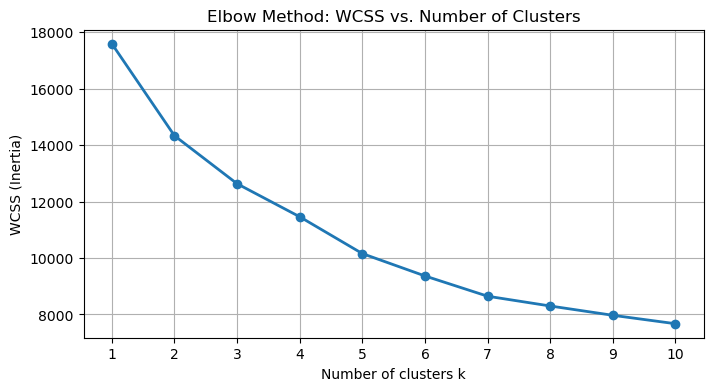

In [1009]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the data
df = pd.read_csv('winequality-red.csv')

# Select the numerical features only
features = df.drop(columns=['quality'])
feature_names = features.columns

# Standardize features by using standard scaler
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Elbow Method: compute WCSS (Within-Cluster Sum of Squares)
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k,
                init='k-means++',
                n_init=10,
                random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, 'o-', linewidth=2)
plt.title('Elbow Method: WCSS vs. Number of Clusters')
plt.xlabel('Number of clusters k')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

## 2.3 Cluster Findings

K-Means with k = 3 (chosen from the elbow plot) was run on the standardised features, with `quality` excluded from clustering. The PCA plot shows the clusters separate mainly along PC1 and PC2 but partly overlap at the edges, which is expected because wine chemistry changes gradually. Using the centroids (original scale) the clusters can be described as:

- **Cluster 0 – softer, less acidic wines:** lower fixed acidity (7.19), higher pH (3.41), low citric acid (0.12) and comparatively higher volatile acidity (0.61).
- **Cluster 1 – acidic, full-bodied wines:** high fixed acidity (10.07), citric acid (0.47), density (0.998), sulphates (0.75) and chlorides (0.10), with the lowest pH (3.20) and the highest alcohol (10.72).
- **Cluster 2 – high sulphur dioxide wines:** very high free SO2 (27.1) and total SO2 (90.0), the highest residual sugar (3.11) and the lowest alcohol (9.88).

Overall, the clusters are driven mainly by acidity/pH (Clusters 0 vs 1) and by sulphur dioxide levels (Cluster 2), showing that the wines fall into three chemically distinct groups.

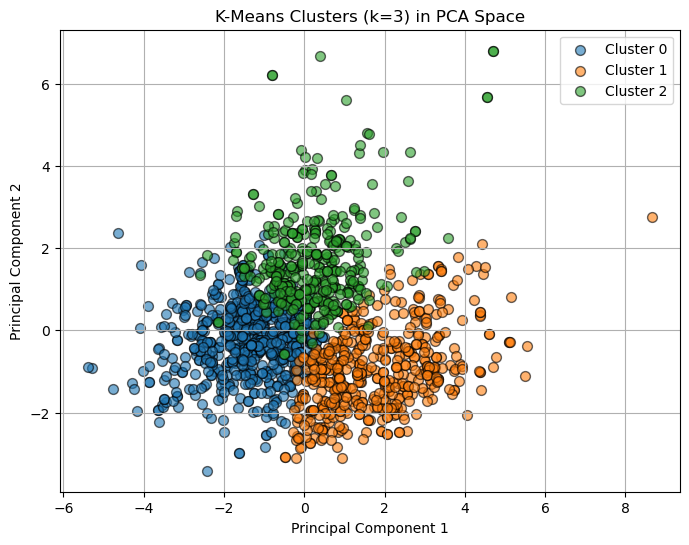

In [1011]:
# Fit K-Means with the chosen k
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal,
                init='k-means++',
                n_init=10,
                random_state=42)
labels = kmeans.fit_predict(X)
df['cluster'] = labels

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X)
df['PC1'] = components[:, 0]
df['PC2'] = components[:, 1]

# Plot the clusters in PCA space
plt.figure(figsize=(8, 6))
for cluster in range(k_optimal):
    subset = df[df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f'Cluster {cluster}',
                alpha=0.6,
                edgecolor='k',
                s=50)
plt.title(f'K-Means Clusters (k={k_optimal}) in PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [1012]:
# Examine cluster centroids (mean feature values)
cluster_centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=feature_names
)
cluster_centroids.index.name = 'Cluster'
print("\nCluster Centroids (in original feature scale):")
print(cluster_centroids.round(3))


Cluster Centroids (in original feature scale):
         fixed acidity  volatile acidity  citric acid  residual sugar  \
Cluster                                                                 
0                7.190             0.609        0.123           2.214   
1               10.067             0.405        0.470           2.583   
2                8.155             0.535        0.290           3.105   

         chlorides  free sulfur dioxide  total sulfur dioxide  density     pH  \
Cluster                                                                         
0            0.079               13.508                34.895    0.996  3.406   
1            0.100               10.888                30.627    0.998  3.195   
2            0.087               27.108                89.955    0.997  3.284   

         sulphates  alcohol  
Cluster                      
0            0.609   10.494  
1            0.752   10.724  
2            0.627    9.883  


---
## Summary

- **Classification:** SVM (RBF, C=4.3) reached ~58% accuracy versus ~57% for Random Forest on a 10-class genre problem. Errors concentrate in genres that overlap in audio features (Rap/Hip-hop, Alternative/Rock/Country).
- **Clustering:** K-Means (k = 3) on standardised wine chemistry produced three interpretable groups driven by acidity/pH and sulphur dioxide levels.
- **Practices applied:** stratified splitting, leakage-free scaling (`fit` on train, `transform` elsewhere), class balancing, per-class evaluation and cluster interpretation via centroids.

**Possible next steps:** hyperparameter search (grid/random search with cross-validation), engineered features, gradient boosting, and testing cluster stability with silhouette scores.